In [ ]:

# ----- Imports & Settings -----
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility (feel free to change the seed)
np.random.seed(42)

# Matplotlib: make figures a bit larger by default
plt.rcParams["figure.figsize"] = (8, 5)

print("Ready!")


Ready!


## Bandit Environment

In [ ]:

class KArmedBandit:
    """
    k-armed bandit with Gaussian rewards.

    Parameters
    ----------
    k : int
        Number of arms/actions.
    mu_mean : float
        Mean of the prior used to sample each arm's true mean.
    mu_std : float
        Std dev of the prior for true means.
    reward_std : float
        Std dev of reward noise.
    nonstationary : bool
        If True, the true means drift each step by N(0, drift_std).
    drift_std : float
        Std dev for the random walk drift of true means when nonstationary is True.
    """
    def __init__(self, k=10, mu_mean=0.0, mu_std=1.0, reward_std=1.0,
                 nonstationary=False, drift_std=0.01):
        self.k = k
        self.reward_std = reward_std
        self.nonstationary = nonstationary
        self.drift_std = drift_std

        # Sample true means for each arm
        self.true_means = np.random.normal(mu_mean, mu_std, size=k)

    def step(self, action):
        """
        Pull the chosen arm 'action' and return a reward ~ N(true_mean[action], reward_std^2).
        If nonstationary, the true means will randomly drift afterward.
        """
        reward = np.random.normal(self.true_means[action], self.reward_std)

        if self.nonstationary:
            # Random walk on true means
            self.true_means += np.random.normal(0.0, self.drift_std, size=self.k)

        return reward

    def optimal_action(self):
        """Return the index of the current optimal arm (highest true mean)."""
        return int(np.argmax(self.true_means))

    def snapshot_true_means(self):
        """Safely copy the current true means (useful for plotting)."""
        return self.true_means.copy()


## Agent: epsilon-Greedy Q-Learning (Action-Value Method)

In [ ]:

def run_bandit_experiment(
    steps=1000,
    runs=200,
    k=10,
    epsilon=0.1,
    alpha=None,                # None => sample-average; else constant step-size in (0, 1]
    optimistic_init=0.0,       # e.g., 5.0 to encourage exploration
    nonstationary=False,
    drift_std=0.01,
    reward_std=1.0,
):
    """
    Run multiple runs (independent bandits) to get averaged learning curves.

    Returns
    -------
    avg_rewards : (steps,) average reward at each step across runs
    optimal_action_perc : (steps,) percentage (0..100) of times the optimal action was taken
    final_Q : (k,) average of learned Q-values across runs at the final step
    final_true_means : (k,) average of true means across runs at the final step
    action_counts : (k,) average number of times each action was taken across runs
    """
    avg_rewards = np.zeros(steps)
    optimal_action_hits = np.zeros(steps)  # count how often we picked the optimal arm
    final_Q_accum = np.zeros(k)            # accumulate across runs for inspection
    final_mu_accum = np.zeros(k)
    action_counts_accum = np.zeros(k)

    for r in range(runs):
        bandit = KArmedBandit(k=k, nonstationary=nonstationary, drift_std=drift_std, reward_std=reward_std)

        # Q estimates and action counts
        Q = np.ones(k) * optimistic_init  # optimistic (or zeros if 0)
        N = np.zeros(k)                   # action counts

        for t in range(steps):
            # A: epsilon-greedy action selection
            if np.random.rand() < epsilon:
                a = np.random.randint(k)
            else:
                # break ties randomly to avoid always picking the first max
                a = int(np.random.choice(np.flatnonzero(Q == Q.max())))

            # Track whether this action was optimal before the step is taken
            optimal = (a == bandit.optimal_action())

            # B: interact with environment
            reward = bandit.step(a)

            # C: update counts and Q
            N[a] += 1
            if alpha is None:
                # sample-average step size: 1/N[a]
                step_size = 1.0 / N[a]
            else:
                # constant step size (useful in nonstationary problems)
                step_size = alpha

            # incremental update rule
            Q[a] += step_size * (reward - Q[a])

            # D: logging for this time-step
            avg_rewards[t] += reward
            if optimal:
                optimal_action_hits[t] += 1

        # accumulate summary stats for this run (final step view)
        final_Q_accum += Q
        final_mu_accum += bandit.snapshot_true_means()
        action_counts_accum += N

    # average across runs
    avg_rewards /= runs
    optimal_action_perc = 100.0 * optimal_action_hits / runs
    final_Q = final_Q_accum / runs
    final_true_means = final_mu_accum / runs
    action_counts = action_counts_accum / runs

    return avg_rewards, optimal_action_perc, final_Q, final_true_means, action_counts


## Plotting Helpers

In [ ]:

def plot_curve(y, title, ylabel, xlabel="Steps"):
    """Plot a single curve with labels."""
    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.show()


def bar_plot(values, title, xlabel="Arms", ylabel="Value"):
    """Simple bar chart (no custom colors)."""
    import matplotlib.pyplot as plt
    import numpy as np
    plt.figure()
    plt.bar(np.arange(len(values)), values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


def compare_methods_curves(curves, labels, title, xlabel="Steps", ylabel="Metric"):
    """
    Plot multiple curves (e.g., for different epsilons) on the same figure.
    curves: list of 1D arrays
    labels: list of strings
    """
    import matplotlib.pyplot as plt
    plt.figure()
    for y, lab in zip(curves, labels):
        plt.plot(y, label=lab)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## Baseline: Stationary Bandit, epsilon = 0.1

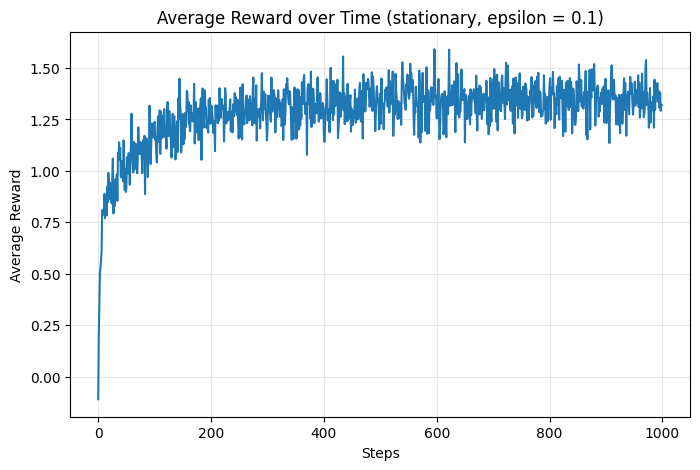

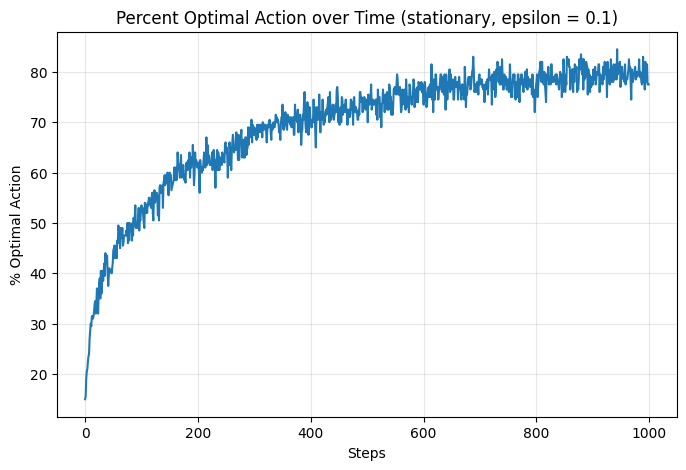

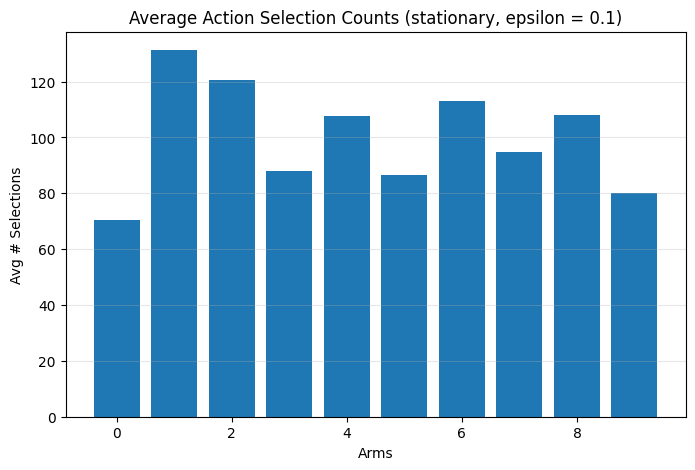

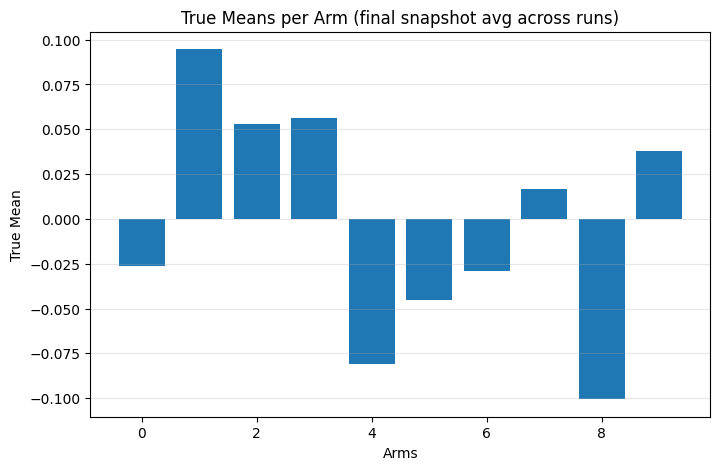

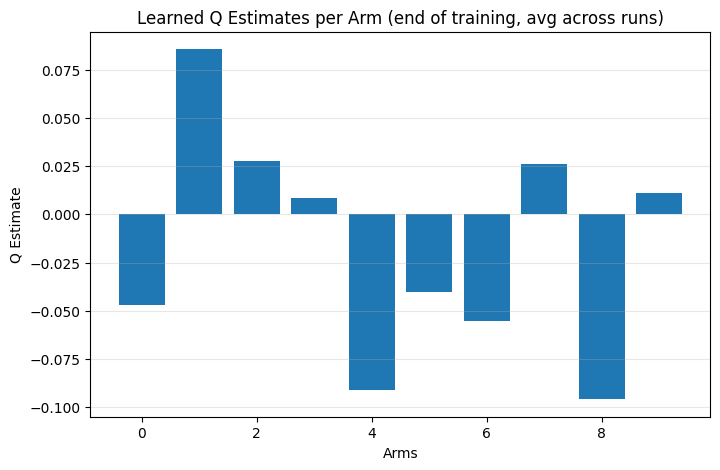

Done.


In [ ]:

steps = 1000
runs = 200
k = 10

avg_rewards, opt_pct, Q_final, mu_final, action_counts = run_bandit_experiment(
    steps=steps, runs=runs, k=k, epsilon=0.1, alpha=None, optimistic_init=0.0,
    nonstationary=False
)

plot_curve(avg_rewards, "Average Reward over Time (stationary, epsilon = 0.1)", "Average Reward")
plot_curve(opt_pct, "Percent Optimal Action over Time (stationary, epsilon = 0.1)", "% Optimal Action")
bar_plot(action_counts, "Average Action Selection Counts (stationary, epsilon = 0.1)", ylabel="Avg # Selections")
bar_plot(mu_final, "True Means per Arm (final snapshot avg across runs)", ylabel="True Mean")
bar_plot(Q_final, "Learned Q Estimates per Arm (end of training, avg across runs)", ylabel="Q Estimate")

print("Done.")


## Compare epsilon values: 0 (greedy), 0.01, 0.1

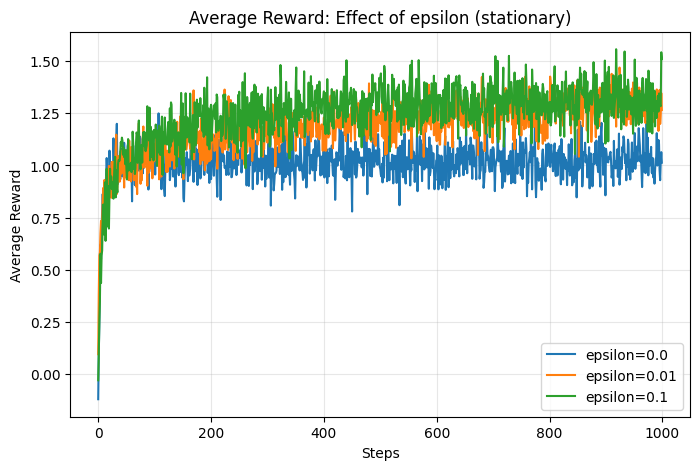

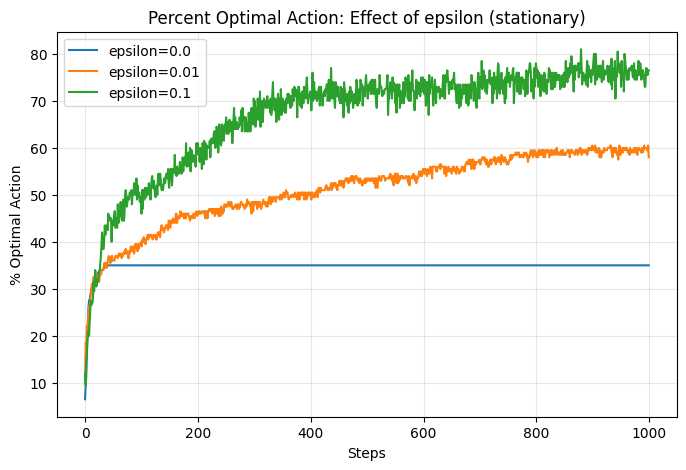

In [ ]:

eps_list = [0.0, 0.01, 0.1]
rewards_curves = []
opt_curves = []

for eps in eps_list:
    avg_rewards_eps, opt_pct_eps, *_ = run_bandit_experiment(
        steps=steps, runs=runs, k=k, epsilon=eps, alpha=None, optimistic_init=0.0,
        nonstationary=False
    )
    rewards_curves.append(avg_rewards_eps)
    opt_curves.append(opt_pct_eps)

compare_methods_curves(rewards_curves, [f"epsilon={e}" for e in eps_list],
                       "Average Reward: Effect of epsilon (stationary)", ylabel="Average Reward")
compare_methods_curves(opt_curves, [f"epsilon={e}" for e in eps_list],
                       "Percent Optimal Action: Effect of epsilon (stationary)", ylabel="% Optimal Action")


## Optimistic Initial Values Encourage Early Exploration

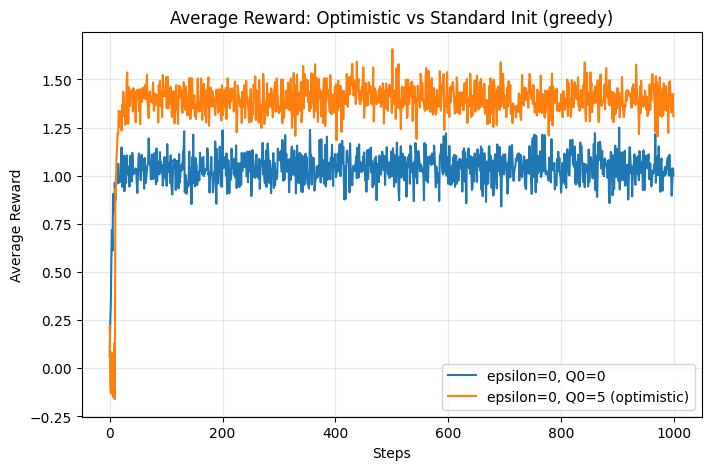

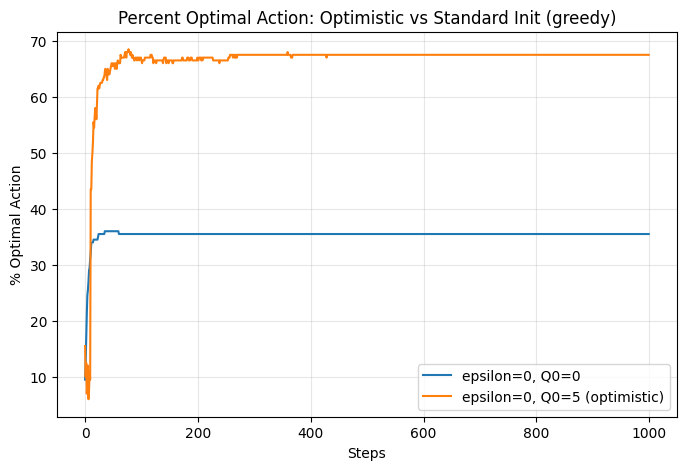

In [ ]:

# Compare standard zero init vs optimistic init
avg_rewards_zero, opt_zero, *_ = run_bandit_experiment(
    steps=steps, runs=runs, k=k, epsilon=0.0, alpha=None, optimistic_init=0.0,
    nonstationary=False
)

avg_rewards_opt, opt_opt, *_ = run_bandit_experiment(
    steps=steps, runs=runs, k=k, epsilon=0.0, alpha=None, optimistic_init=5.0,
    nonstationary=False
)

compare_methods_curves([avg_rewards_zero, avg_rewards_opt],
                       ["epsilon=0, Q0=0", "epsilon=0, Q0=5 (optimistic)"],
                       "Average Reward: Optimistic vs Standard Init (greedy)",
                       ylabel="Average Reward")

compare_methods_curves([opt_zero, opt_opt],
                       ["epsilon=0, Q0=0", "epsilon=0, Q0=5 (optimistic)"],
                       "Percent Optimal Action: Optimistic vs Standard Init (greedy)",
                       ylabel="% Optimal Action")


## Non-Stationary Bandit: Constant Step-Size vs Sample-Average

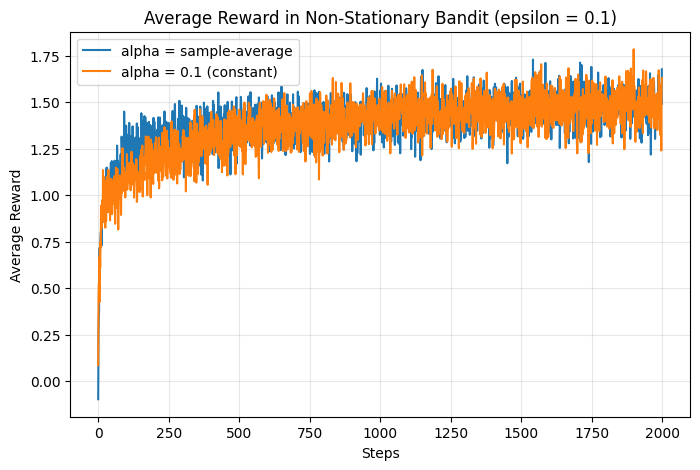

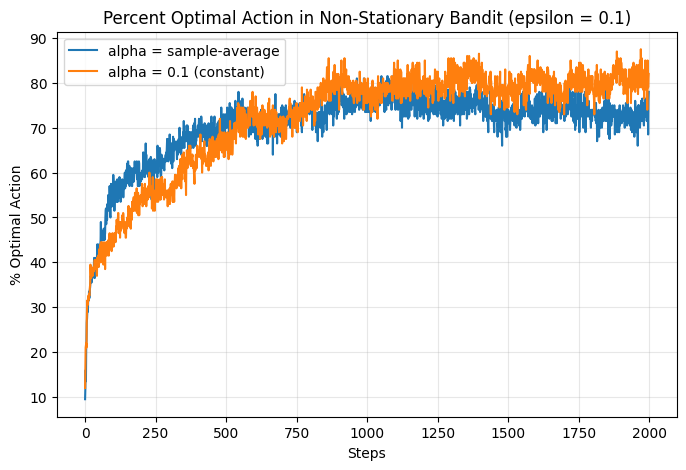

In [ ]:

# In non-stationary problems, a constant step size (alpha) is usually better.
# We compare alpha=None (sample-average) vs alpha=0.1

steps_ns = 2000
rewards_avg, opt_avg, *_ = run_bandit_experiment(
    steps=steps_ns, runs=runs, k=k, epsilon=0.1, alpha=None, optimistic_init=0.0,
    nonstationary=True, drift_std=0.01
)
rewards_const, opt_const, *_ = run_bandit_experiment(
    steps=steps_ns, runs=runs, k=k, epsilon=0.1, alpha=0.1, optimistic_init=0.0,
    nonstationary=True, drift_std=0.01
)

compare_methods_curves([rewards_avg, rewards_const],
                       ["alpha = sample-average", "alpha = 0.1 (constant)"],
                       "Average Reward in Non-Stationary Bandit (epsilon = 0.1)",
                       xlabel="Steps", ylabel="Average Reward")
compare_methods_curves([opt_avg, opt_const],
                       ["alpha = sample-average", "alpha = 0.1 (constant)"],
                       "Percent Optimal Action in Non-Stationary Bandit (epsilon = 0.1)",
                       xlabel="Steps", ylabel="% Optimal Action")


## Try Your Own Settings

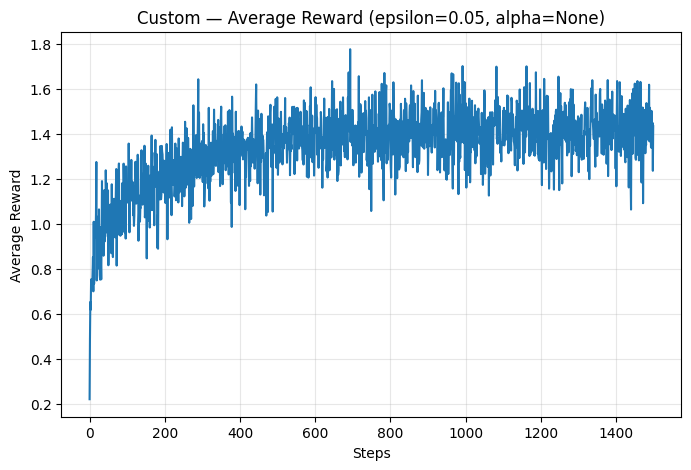

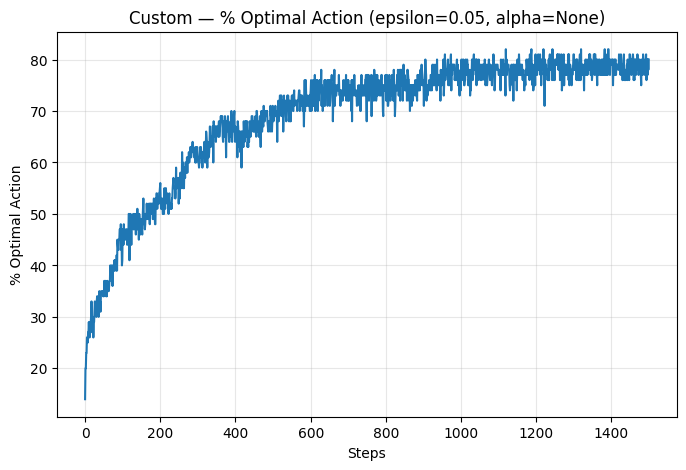

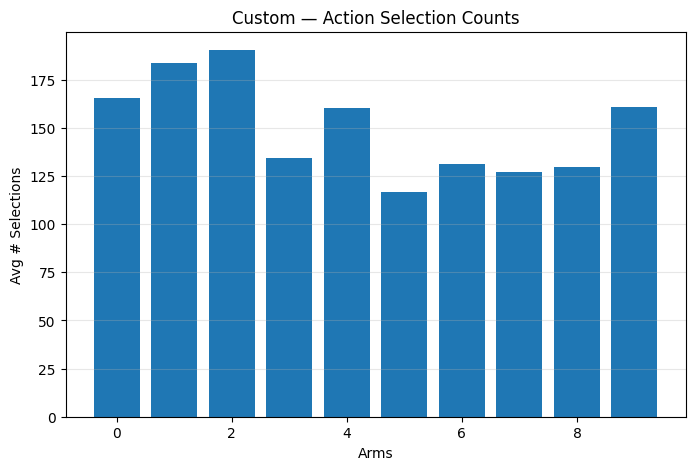

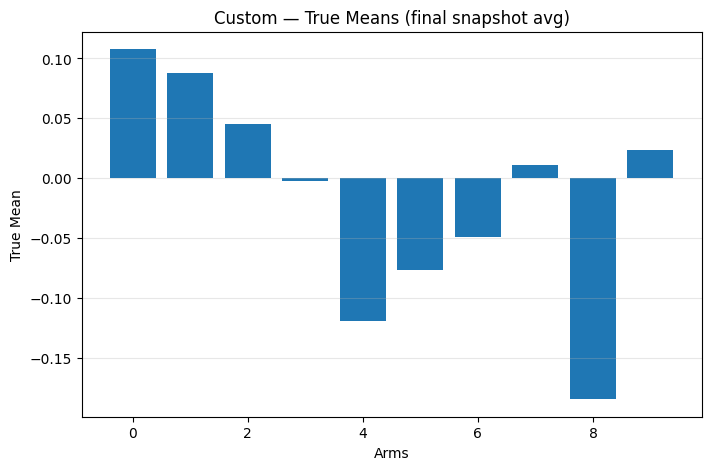

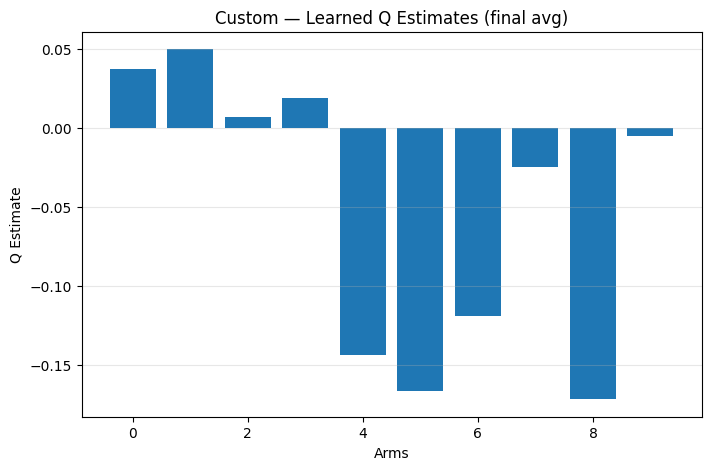

Experiment finished.


In [ ]:

# Feel free to change these and re-run this cell!
custom = dict(steps=1500, runs=100, k=10, epsilon=0.05, alpha=None,
              optimistic_init=0.0, nonstationary=False, drift_std=0.01, reward_std=1.0)

avg_r, opt_p, Qf, muf, N = run_bandit_experiment(**custom)
plot_curve(avg_r, f"Custom — Average Reward (epsilon={custom['epsilon']}, alpha={custom['alpha']})", "Average Reward")
plot_curve(opt_p,  f"Custom — % Optimal Action (epsilon={custom['epsilon']}, alpha={custom['alpha']})", "% Optimal Action")
bar_plot(N,      "Custom — Action Selection Counts", ylabel="Avg # Selections")
bar_plot(muf,    "Custom — True Means (final snapshot avg)", ylabel="True Mean")
bar_plot(Qf,     "Custom — Learned Q Estimates (final avg)", ylabel="Q Estimate")
print("Experiment finished.")



### References (Suggested Reading)
- Sutton & Barto, Reinforcement Learning: An Introduction (2nd ed.). See Chapter 2: Multi-armed Bandits.
- Richard S. Sutton (1988), Learning to Predict by the Methods of Temporal Differences.
